In [1]:
import pandas as pd
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin-1')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [2]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check unique values in key categorical/date columns
print("\nDelivery Status values:", df['Delivery Status'].unique())
print("\nLate_delivery_risk values:", df['Late_delivery_risk'].unique())
print("\nShipping Mode values:", df['Shipping Mode'].unique())
print("\nCustomer Country values:", df['Customer Country'].unique())

# Check date columns — are they actually formatted as dates or just strings?
print("\nSample order date:", df['order date (DateOrders)'].iloc[0] if 'order date (DateOrders)' in df.columns else "column name differs")
print("Sample shipping date:", df['shipping date (DateOrders)'].iloc[0])

Duplicate rows: 0

Delivery Status values: <ArrowStringArray>
['Advance shipping', 'Late delivery', 'Shipping on time', 'Shipping canceled']
Length: 4, dtype: str

Late_delivery_risk values: [0 1]

Shipping Mode values: <ArrowStringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str

Customer Country values: <ArrowStringArray>
['Puerto Rico', 'EE. UU.']
Length: 2, dtype: str

Sample order date: 1/31/2018 22:56
Sample shipping date: 2/3/2018 22:56


In [3]:
# Check how Delivery Status maps to Late_delivery_risk
print(pd.crosstab(df['Delivery Status'], df['Late_delivery_risk']))

# Check other key categorical columns for messiness
for col in ['Category Name', 'Customer State', 'Market', 'Order Region', 'Order Country', 'Order Status']:
    if col in df.columns:
        print(f"\n{col} — {df[col].nunique()} unique values:")
        print(df[col].unique()[:15])  # first 15 to avoid huge output

Late_delivery_risk      0      1
Delivery Status                 
Advance shipping    41592      0
Late delivery           0  98977
Shipping canceled    7754      0
Shipping on time    32196      0

Category Name — 50 unique values:
<ArrowStringArray>
[      'Sporting Goods',               'Cleats',        'Shop By Sport',
      'Women's Apparel',          'Electronics',         'Boxing & MMA',
     'Cardio Equipment',             'Trade-In',     'Kids' Golf Clubs',
   'Hunting & Shooting',  'Baseball & Softball',       'Men's Footwear',
     'Camping & Hiking', 'Consumer Electronics',             'Cameras ']
Length: 15, dtype: str

Customer State — 46 unique values:
<ArrowStringArray>
['PR', 'CA', 'NY', 'FL', 'MA', 'IL', 'MT', 'PA', 'MI', 'TX', 'DE', 'GA', 'MD',
 'OH', 'HI']
Length: 15, dtype: str

Market — 5 unique values:
<ArrowStringArray>
['Pacific Asia', 'USCA', 'Africa', 'Europe', 'LATAM']
Length: 5, dtype: str

Order Region — 23 unique values:
<ArrowStringArray>
[ 'Southeast As

In [4]:
print(list(df.columns))

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

In [5]:
# Check these before deciding to drop
check_cols = ['Product Description', 'Product Image', 'Product Status', 'Order Zipcode',
              'Order Customer Id', 'Customer Id', 'Category Id', 'Product Category Id',
              'Order Item Cardprod Id', 'Product Card Id']

for col in check_cols:
    print(f"{col}: nulls={df[col].isnull().sum()}, unique={df[col].nunique()}, sample={df[col].dropna().unique()[:3]}")

Product Description: nulls=180519, unique=0, sample=[]
Product Image: nulls=0, unique=118, sample=<ArrowStringArray>
[                                          'http://images.acmesports.sports/Smart+watch ',
                       'http://images.acmesports.sports/Perfect+Fitness+Perfect+Rip+Deck',
 'http://images.acmesports.sports/Under+Armour+Girls%27+Toddler+Spine+Surge+Running+Shoe']
Length: 3, dtype: str
Product Status: nulls=0, unique=1, sample=[0]
Order Zipcode: nulls=155679, unique=609, sample=[99301. 90049. 94110.]
Order Customer Id: nulls=0, unique=20652, sample=[20755 19492 19491]
Customer Id: nulls=0, unique=20652, sample=[20755 19492 19491]
Category Id: nulls=0, unique=51, sample=[73 17 29]
Product Category Id: nulls=0, unique=51, sample=[73 17 29]
Order Item Cardprod Id: nulls=0, unique=118, sample=[1360  365  627]
Product Card Id: nulls=0, unique=118, sample=[1360  365  627]


In [6]:
# 1. Drop PII columns
pii_cols = ['Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
            'Customer Street', 'Customer Zipcode', 'Latitude', 'Longitude']
df = df.drop(columns=pii_cols)

# 2. Drop empty/redundant/low-value columns
redundant_cols = ['Product Description', 'Product Image', 'Product Status', 'Order Zipcode',
                   'Order Customer Id', 'Product Category Id', 'Order Item Cardprod Id']
df = df.drop(columns=redundant_cols)

# 3. Fix inconsistent country naming
df['Customer Country'] = df['Customer Country'].replace({'EE. UU.': 'United States'})
df['Order Country'] = df['Order Country'].replace({'EE. UU.': 'Estados Unidos'})  # verify below first

# 4. Convert date columns to real datetime
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# 5. Engineer delivery delay feature
df['delivery_delay_days'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# 6. Final check
print("Shape after cleaning:", df.shape)
print("\nRemaining nulls:\n", df.isnull().sum().sort_values(ascending=False).head(10))
df.info()

Shape after cleaning: (180519, 39)

Remaining nulls:
 Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  str           
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   De

In [7]:
print(df['Customer Country'].unique())
print(df['Order Country'].unique())

<ArrowStringArray>
['Puerto Rico', 'United States']
Length: 2, dtype: str
<ArrowStringArray>
[          'Indonesia',               'India',           'Australia',
               'China',               'Japón',       'Corea del Sur',
            'Singapur',             'Turquía',            'Mongolia',
      'Estados Unidos',
 ...
           'Eslovenia', 'República de Gambia',            'Botsuana',
             'Armenia',   'Guinea Ecuatorial',              'Kuwait',
               'Bután',                'Chad',              'Serbia',
   'Sáhara Occidental']
Length: 164, dtype: str


In [9]:
df.to_csv('../data/raw/cleaned_orders.csv', index=False)
print("Saved:", df.shape)

Saved: (180519, 39)


In [10]:
print(df['Order Country'].value_counts().head(20))

Order Country
Estados Unidos          24840
Francia                 13222
México                  13172
Alemania                 9564
Australia                8497
Brasil                   7987
Reino Unido              7302
China                    5758
Italia                   4989
India                    4783
Indonesia                4204
España                   3868
El Salvador              3726
República Dominicana     3669
Honduras                 3629
Cuba                     3534
Turquía                  3395
Nicaragua                3046
Guatemala                2778
Nigeria                  2309
Name: count, dtype: int64


In [11]:
# Translate top countries (Spanish -> English) - covers majority of order volume
country_translation = {
    'Estados Unidos': 'United States',
    'Francia': 'France',
    'México': 'Mexico',
    'Alemania': 'Germany',
    'Brasil': 'Brazil',
    'Reino Unido': 'United Kingdom',
    'Italia': 'Italy',
    'España': 'Spain',
    'República Dominicana': 'Dominican Republic',
    'Turquía': 'Turkey',
    'Japón': 'Japan',
    'Corea del Sur': 'South Korea',
    'Singapur': 'Singapore',
    'Mongolia': 'Mongolia',
    'Eslovenia': 'Slovenia',
    'República de Gambia': 'Gambia',
    'Botsuana': 'Botswana',
    'Guinea Ecuatorial': 'Equatorial Guinea',
    'Bután': 'Bhutan',
    'Sáhara Occidental': 'Western Sahara',
}

df['Order Country'] = df['Order Country'].replace(country_translation)

# Check how much of the data is now clean vs still untranslated
print("Remaining unique values:", df['Order Country'].nunique())
print(df['Order Country'].value_counts().head(25))

Remaining unique values: 164
Order Country
United States         24840
France                13222
Mexico                13172
Germany                9564
Australia              8497
Brazil                 7987
United Kingdom         7302
China                  5758
Italy                  4989
India                  4783
Indonesia              4204
Spain                  3868
El Salvador            3726
Dominican Republic     3669
Honduras               3629
Cuba                   3534
Turkey                 3395
Nicaragua              3046
Guatemala              2778
Nigeria                2309
Filipinas              2103
Panamá                 1941
Países Bajos           1932
Argentina              1931
Colombia               1771
Name: count, dtype: int64


In [12]:
df.to_csv('../data/raw/cleaned_orders.csv', index=False)
print("Saved:", df.shape)

Saved: (180519, 39)


In [13]:
more_translations = {
    'Filipinas': 'Philippines',
    'Panamá': 'Panama',
    'Países Bajos': 'Netherlands',
}
df['Order Country'] = df['Order Country'].replace(more_translations)

print(df['Order Country'].value_counts().head(25))

Order Country
United States         24840
France                13222
Mexico                13172
Germany                9564
Australia              8497
Brazil                 7987
United Kingdom         7302
China                  5758
Italy                  4989
India                  4783
Indonesia              4204
Spain                  3868
El Salvador            3726
Dominican Republic     3669
Honduras               3629
Cuba                   3534
Turkey                 3395
Nicaragua              3046
Guatemala              2778
Nigeria                2309
Philippines            2103
Panama                 1941
Netherlands            1932
Argentina              1931
Colombia               1771
Name: count, dtype: int64


In [16]:
df.to_csv('../data/processed/cleaned_orders.csv', index=False)

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/cleaned_orders.csv')
df.info()

Matplotlib is building the font cache; this may take a moment.


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment               180519 non

## EDA

In [18]:
# Late delivery rate by region
region_risk = df.groupby('Order Region')['Late_delivery_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False)
region_risk['mean'] = (region_risk['mean'] * 100).round(1)
region_risk.columns = ['Late Delivery Rate (%)', 'Order Count']
print(region_risk)

                 Late Delivery Rate (%)  Order Count
Order Region                                        
Central Africa                     58.0         1677
South Asia                         56.3         7731
East Africa                        55.9         1852
Western Europe                     55.8        27109
South of  USA                      55.8         4045
Eastern Europe                     55.7         3920
East of USA                        55.7         6915
Southeast Asia                     55.5         9539
Central Asia                       55.3          553
West Asia                          55.3         6009
US Center                          55.2         5887
Central America                    54.8        28341
North Africa                       54.5         3232
Southern Europe                    54.4         9431
Eastern Asia                       54.3         7280
South America                      54.3        14935
Northern Europe                    54.0       

In [19]:
category_risk = df.groupby('Category Name')['Late_delivery_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False)
category_risk['mean'] = (category_risk['mean'] * 100).round(1)
category_risk.columns = ['Late Delivery Rate (%)', 'Order Count']
print(category_risk.head(15))  

                     Late Delivery Rate (%)  Order Count
Category Name                                           
Golf Bags & Carts                      68.9           61
Lacrosse                               60.1          343
Pet Supplies                           58.9          492
Cameras                                58.1          592
Strength Training                      57.7          111
As Seen on  TV!                        57.4           68
Music                                  57.1          434
Accessories                            57.0         1780
Fitness Accessories                    57.0          309
Books                                  56.5          405
Women's Clothing                       56.5          650
Boxing & MMA                           56.3          423
Golf Gloves                            56.3         1070
Hunting & Shooting                     56.1          440
Electronics                            56.1         3156


In [20]:
print("Overall late delivery rate:", round(df['Late_delivery_risk'].mean() * 100, 1), "%")

Overall late delivery rate: 54.8 %


In [22]:
shipping_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False)
shipping_risk['mean'] = (shipping_risk['mean'] * 100).round(1)
shipping_risk.columns = ['Late Delivery Rate (%)', 'Order Count']
print(shipping_risk)

                Late Delivery Rate (%)  Order Count
Shipping Mode                                      
First Class                       95.3        27814
Second Class                      76.6        35216
Same Day                          45.7         9737
Standard Class                    38.1       107752


In [23]:
shipping_days = df.groupby('Shipping Mode')['Days for shipment (scheduled)'].mean().sort_values()
print(shipping_days)

Shipping Mode
Same Day          0.0
First Class       1.0
Second Class      2.0
Standard Class    4.0
Name: Days for shipment (scheduled), dtype: float64


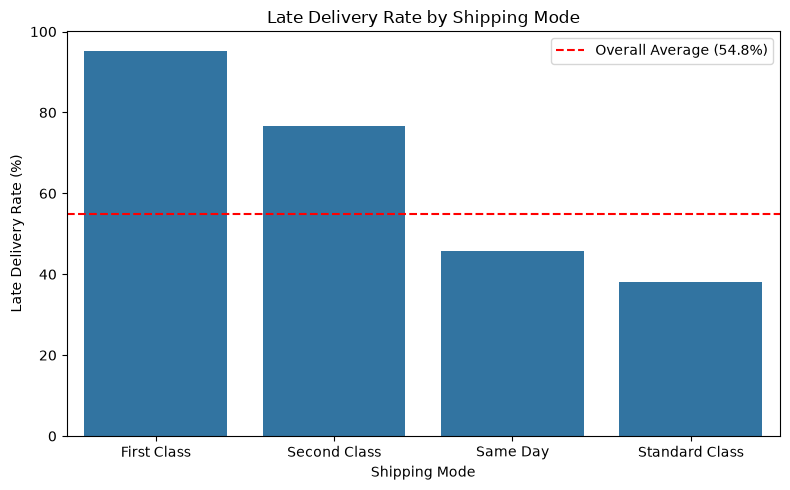

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x=shipping_risk.index, y=shipping_risk['Late Delivery Rate (%)'], order=shipping_risk.sort_values('Late Delivery Rate (%)', ascending=False).index)
plt.title('Late Delivery Rate by Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.xlabel('Shipping Mode')
plt.axhline(54.8, color='red', linestyle='--', label='Overall Average (54.8%)')
plt.legend()
plt.tight_layout()
plt.savefig('../powerbi/shipping_mode_chart.png')
plt.show()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delivery_delay_days, dtype: float64


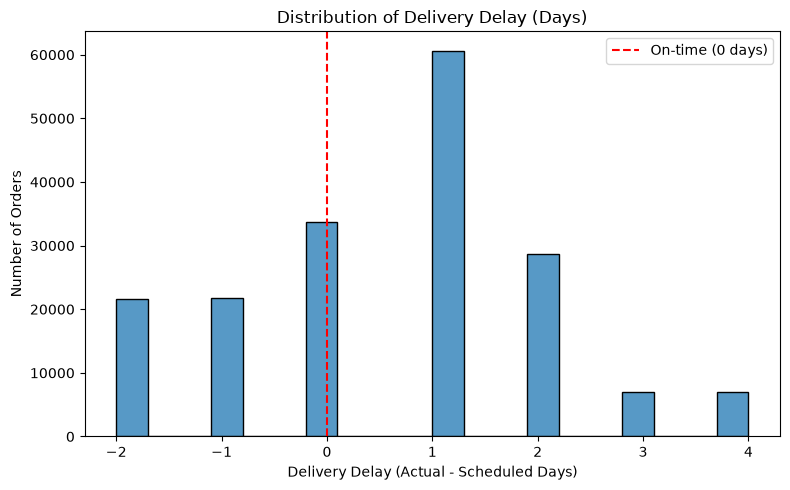

In [25]:
print(df['delivery_delay_days'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['delivery_delay_days'], bins=20, kde=False)
plt.title('Distribution of Delivery Delay (Days)')
plt.xlabel('Delivery Delay (Actual - Scheduled Days)')
plt.ylabel('Number of Orders')
plt.axvline(0, color='red', linestyle='--', label='On-time (0 days)')
plt.legend()
plt.tight_layout()
plt.savefig('../powerbi/delay_distribution_chart.png')
plt.show()

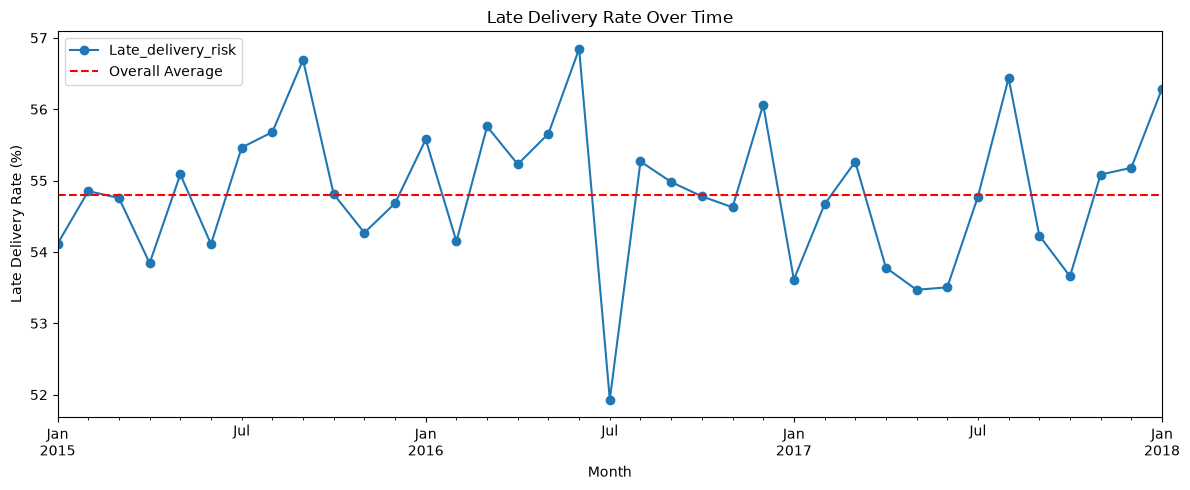

In [26]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['order_month'] = df['order date (DateOrders)'].dt.to_period('M')

monthly_trend = df.groupby('order_month')['Late_delivery_risk'].mean() * 100

plt.figure(figsize=(12,5))
monthly_trend.plot(kind='line', marker='o')
plt.title('Late Delivery Rate Over Time')
plt.ylabel('Late Delivery Rate (%)')
plt.xlabel('Month')
plt.axhline(54.8, color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.savefig('../powerbi/trend_chart.png')
plt.show()